In [ ]:
!pip -q install lpips scikit-image diffusers transformers accelerate safetensors huggingface_hub

In [1]:
import os
import gc
import math
import time
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from tqdm.auto import tqdm

from diffusers import StableDiffusionInpaintPipeline, DDPMScheduler
from huggingface_hub import login

from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric
import lpips

print("All imports loaded successfully.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


All imports loaded successfully.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.backends.cudnn.benchmark = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Device: cuda


In [3]:
BASE_DIR = Path("/kaggle/working/studentC_celeba_inpainting")
CKPT_DIR = BASE_DIR / "checkpoints"
RESULT_DIR = BASE_DIR / "results"
SAMPLE_DIR = BASE_DIR / "samples"

CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("CKPT_DIR:", CKPT_DIR)
print("RESULT_DIR:", RESULT_DIR)
print("SAMPLE_DIR:", SAMPLE_DIR)

BASE_DIR: /kaggle/working/studentC_celeba_inpainting
CKPT_DIR: /kaggle/working/studentC_celeba_inpainting/checkpoints
RESULT_DIR: /kaggle/working/studentC_celeba_inpainting/results
SAMPLE_DIR: /kaggle/working/studentC_celeba_inpainting/samples


In [11]:
train_csv_path = "/kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_dataset/train_3000.csv"
val_csv_path = "/kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_dataset/val_500.csv"
test_csv_path = "/kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_dataset/test_500.csv"

image_root = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba"

print("train_csv_path:", train_csv_path)
print("val_csv_path:", val_csv_path)
print("test_csv_path:", test_csv_path)
print("image_root:", image_root)

train_csv_path: /kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_dataset/train_3000.csv
val_csv_path: /kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_dataset/val_500.csv
test_csv_path: /kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_dataset/test_500.csv
image_root: /kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba


In [12]:
EXPERIMENT_MODE = "fast"   # "fast" or "full"

if EXPERIMENT_MODE == "fast":
    TRAIN_LIMIT = 500
    VAL_LIMIT = 100
    TEST_LIMIT = 100
    EPOCHS = 6
else:
    TRAIN_LIMIT = None
    VAL_LIMIT = None
    TEST_LIMIT = None
    EPOCHS = 15

print("Mode:", EXPERIMENT_MODE)
print("Train limit:", TRAIN_LIMIT)
print("Val limit:", VAL_LIMIT)
print("Test limit:", TEST_LIMIT)
print("Epochs:", EPOCHS)

Mode: fast
Train limit: 500
Val limit: 100
Test limit: 100
Epochs: 6


In [13]:
CFG = {
    "image_size": 256,
    "batch_size": 1,
    "num_workers": 0,
    "epochs": EPOCHS,
    "lr": 1e-4,
    "num_train_timesteps": 1000,
    "num_sample_steps": 50,
    "teacher_loss_weight": 0.4,
    "lpips_loss_weight": 0.15,
    "train_csv": train_csv_path,
    "val_csv": val_csv_path,
    "test_csv": test_csv_path,
    "image_root": image_root,
    "student": {
        "in_channels": 9,
        "out_channels": 4,
        "base_channels": 96,
        "weight_mask": 4.0
    },
    "masking": {
        "rectangle_prob": 0.25,
        "brush_prob": 0.25,
        "center_prob": 0.25,
        "blob_prob": 0.25
    }
}

print(json.dumps(CFG, indent=2))

{
  "image_size": 256,
  "batch_size": 1,
  "num_workers": 0,
  "epochs": 6,
  "lr": 0.0001,
  "num_train_timesteps": 1000,
  "num_sample_steps": 50,
  "teacher_loss_weight": 0.4,
  "lpips_loss_weight": 0.15,
  "train_csv": "/kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_dataset/train_3000.csv",
  "val_csv": "/kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_dataset/val_500.csv",
  "test_csv": "/kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_dataset/test_500.csv",
  "image_root": "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba",
  "student": {
    "in_channels": 9,
    "out_channels": 4,
    "base_channels": 96,
    "weight_mask": 4.0
  },
  "masking": {
    "rectangle_prob": 0.25,
    "brush_prob": 0.25,
    "center_prob": 0.25,
    "blob_prob": 0.25
  }
}


In [14]:
train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

if TRAIN_LIMIT is not None:
    train_df = train_df.iloc[:TRAIN_LIMIT].copy()

if VAL_LIMIT is not None:
    val_df = val_df.iloc[:VAL_LIMIT].copy()

if TEST_LIMIT is not None:
    test_df = test_df.iloc[:TEST_LIMIT].copy()

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Final dataset sizes:")
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Final dataset sizes:
Train: 500
Val: 100
Test: 100


In [15]:
HF_TOKEN = os.environ.get("HF_TOKEN")

if HF_TOKEN:
    login(token=HF_TOKEN)

teacher_pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "sd2-community/stable-diffusion-2-inpainting",
    torch_dtype=torch.float16
).to(device)

teacher_pipe.set_progress_bar_config(disable=True)

teacher_unet = teacher_pipe.unet.eval()
teacher_vae = teacher_pipe.vae.eval()
teacher_text_encoder = teacher_pipe.text_encoder.eval()
teacher_tokenizer = teacher_pipe.tokenizer

scheduler = DDPMScheduler.from_config(teacher_pipe.scheduler.config)
vae = teacher_vae

for p in teacher_unet.parameters():
    p.requires_grad = False
for p in vae.parameters():
    p.requires_grad = False
for p in teacher_text_encoder.parameters():
    p.requires_grad = False

print("Teacher loaded.")

model_index.json:   0%|          | 0.00/544 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--sd2-community--stable-diffusion-2-inpainting/snapshots/5f74973cbb64c8568780732c17f43eb269d63a0d/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Teacher loaded.


In [16]:
def get_null_text_embeddings(batch_size):
    text_inputs = teacher_tokenizer(
        [""] * batch_size,
        padding="max_length",
        max_length=teacher_tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt"
    )
    input_ids = text_inputs.input_ids.to(device)
    with torch.no_grad():
        prompt_embeds = teacher_text_encoder(input_ids)[0]
    return prompt_embeds

In [17]:
to_tensor_01 = transforms.ToTensor()

def pil_to_tensor_neg1_1(image_pil):
    x = to_tensor_01(image_pil)
    return x * 2.0 - 1.0

def tensor_neg1_1_to_01(x):
    return ((x.clamp(-1, 1) + 1.0) / 2.0).clamp(0, 1)

def tensor_01_to_pil(x):
    x = x.detach().cpu().clamp(0, 1)
    x = (x * 255.0).byte().permute(1, 2, 0).numpy()
    return Image.fromarray(x)

def pil_mask_to_tensor(mask_pil):
    mask_np = np.array(mask_pil.convert("L"), dtype=np.float32) / 255.0
    mask_np = (mask_np > 0.5).astype(np.float32)
    return torch.from_numpy(mask_np).unsqueeze(0)

In [20]:
def make_rectangle_mask_pil(size):
    w, h = size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    rect_w = random.randint(w // 6, w // 2)
    rect_h = random.randint(h // 6, h // 2)
    x1 = random.randint(0, w - rect_w)
    y1 = random.randint(0, h - rect_h)
    x2 = x1 + rect_w
    y2 = y1 + rect_h

    draw.rectangle([x1, y1, x2, y2], fill=255)
    area = ((x2 - x1) * (y2 - y1)) / (w * h)
    return mask, area

def make_random_center_mask_pil(size):
    w, h = size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    rect_w = random.randint(w // 5, w // 2)
    rect_h = random.randint(h // 5, h // 2)

    cx = w // 2 + random.randint(-w // 10, w // 10)
    cy = h // 2 + random.randint(-h // 10, h // 10)

    x1 = max(0, cx - rect_w // 2)
    y1 = max(0, cy - rect_h // 2)
    x2 = min(w, x1 + rect_w)
    y2 = min(h, y1 + rect_h)

    draw.rectangle([x1, y1, x2, y2], fill=255)
    area = ((x2 - x1) * (y2 - y1)) / (w * h)
    return mask, area

def make_blob_mask_pil(size):
    w, h = size
    mask_np = np.zeros((h, w), dtype=np.uint8)

    num_blobs = random.randint(3, 6)
    for _ in range(num_blobs):
        radius = random.randint(min(w, h) // 12, min(w, h) // 5)
        cx = random.randint(radius, w - radius)
        cy = random.randint(radius, h - radius)

        yy, xx = np.ogrid[:h, :w]
        circle = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
        mask_np[circle] = 255

    area = (mask_np > 0).mean()
    return Image.fromarray(mask_np).convert("L"), float(area)

def make_brush_mask_pil(size):
    w, h = size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    num_strokes = random.randint(2, 5)
    for _ in range(num_strokes):
        num_points = random.randint(4, 8)
        points = [(random.randint(0, w - 1), random.randint(0, h - 1)) for _ in range(num_points)]
        width = random.randint(max(8, w // 30), max(16, w // 12))
        draw.line(points, fill=255, width=width)
        for x, y in points:
            r = width // 2
            draw.ellipse((x - r, y - r, x + r, y + r), fill=255)

    mask_np = np.array(mask)
    area = (mask_np > 0).mean()
    return mask, float(area)

def sample_hybrid_mask_pil(size, masking_cfg):
    types = ["rectangle", "brush", "center", "blob"]
    probs = [
        masking_cfg["rectangle_prob"],
        masking_cfg["brush_prob"],
        masking_cfg["center_prob"],
        masking_cfg["blob_prob"]
    ]

    mask_type = random.choices(types, weights=probs, k=1)[0]

    if mask_type == "rectangle":
        mask, area = make_rectangle_mask_pil(size)
    elif mask_type == "brush":
        mask, area = make_brush_mask_pil(size)
    elif mask_type == "center":
        mask, area = make_random_center_mask_pil(size)
    else:
        mask, area = make_blob_mask_pil(size)

    return mask, mask_type, area

In [21]:
def apply_mask_to_image(image_pil, mask_pil):
    image_np = np.array(image_pil).astype(np.uint8)
    mask_np = np.array(mask_pil.convert("L")) > 127
    masked_np = image_np.copy()
    masked_np[mask_np] = 0
    return Image.fromarray(masked_np)

In [22]:
class FixedSubsetImageDataset(Dataset):
    def __init__(self, df, image_root, image_size=256):
        self.df = df.reset_index(drop=True)
        self.image_root = Path(image_root)
        self.image_size = image_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fname = self.df.iloc[idx]["filename"]
        img_path = self.image_root / fname

        img = Image.open(img_path).convert("RGB")
        img = img.resize((self.image_size, self.image_size), Image.BICUBIC)

        return {
            "filename": fname,
            "image_pil": img
        }

In [23]:
train_ds = FixedSubsetImageDataset(train_df, CFG["image_root"], CFG["image_size"])
val_ds = FixedSubsetImageDataset(val_df, CFG["image_root"], CFG["image_size"])
test_ds = FixedSubsetImageDataset(test_df, CFG["image_root"], CFG["image_size"])

print("Train:", len(train_ds))
print("Val:", len(val_ds))
print("Test:", len(test_ds))

Train: 500
Val: 100
Test: 100


In [24]:
def collate_identity(batch):
    return batch

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    collate_fn=collate_identity,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    collate_fn=collate_identity,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_identity,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 500
Val batches: 100
Test batches: 100


In [25]:
sample = train_ds[0]
print(sample.keys())
print(sample["filename"])
print(type(sample["image_pil"]), sample["image_pil"].size)

dict_keys(['filename', 'image_pil'])
111044.jpg
<class 'PIL.Image.Image'> (256, 256)


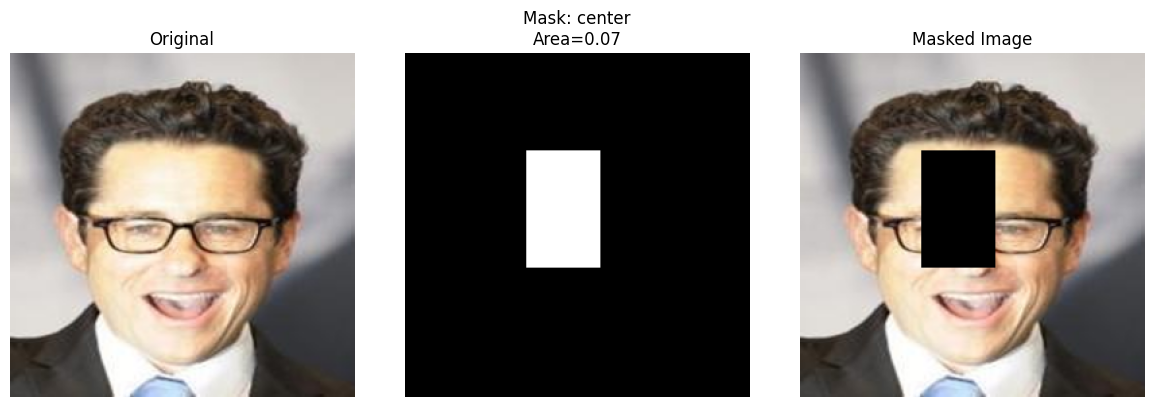

In [26]:
sample_img = train_ds[0]["image_pil"]

mask, mask_type, area = sample_hybrid_mask_pil(sample_img.size, CFG["masking"])
masked_img = apply_mask_to_image(sample_img, mask)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title(f"Mask: {mask_type}\nArea={area:.2f}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(masked_img)
plt.title("Masked Image")
plt.axis("off")

plt.tight_layout()
plt.show()

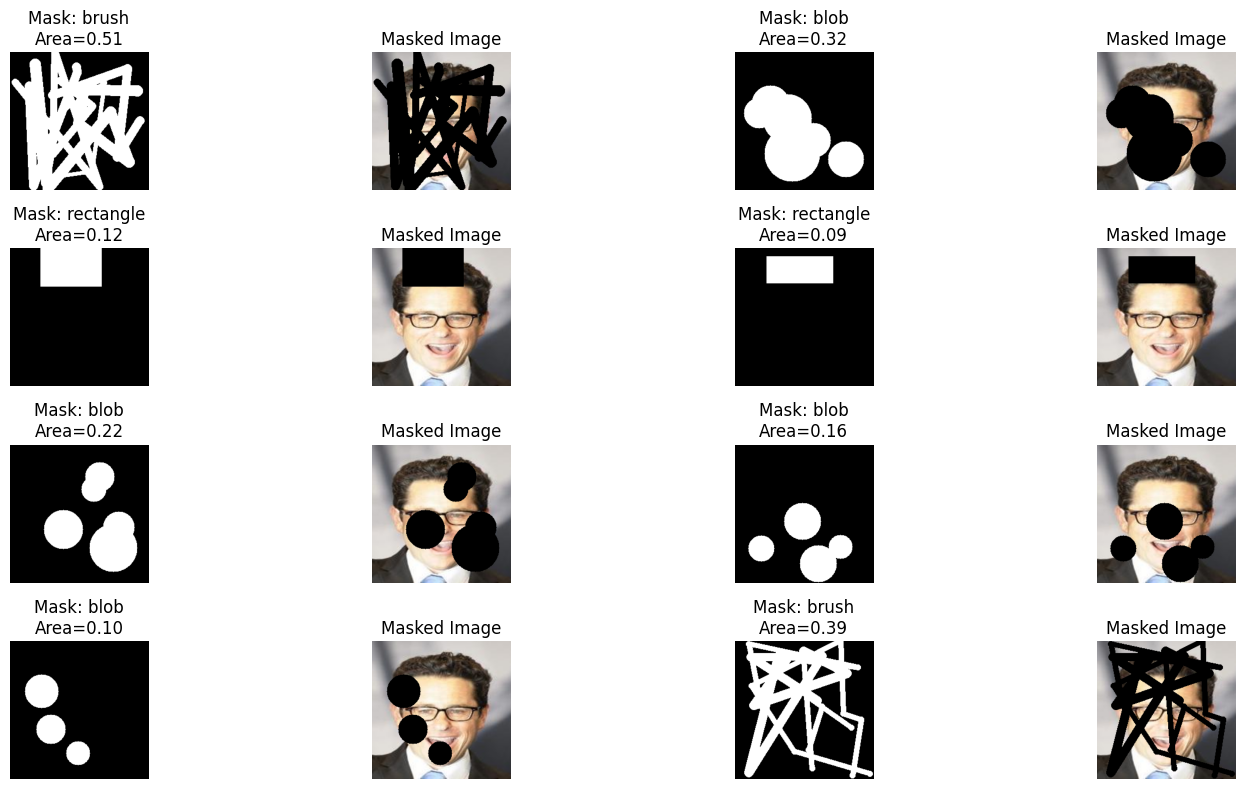

In [28]:
# Preview masking behavior

sample_img = train_ds[0]["image_pil"]

plt.figure(figsize=(16, 8))

for i in range(8):
    mask, mask_type, area = sample_hybrid_mask_pil(sample_img.size, CFG["masking"])
    masked_img = apply_mask_to_image(sample_img, mask)

    plt.subplot(4, 4, 2*i + 1)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Mask: {mask_type}\nArea={area:.2f}")
    plt.axis("off")

    plt.subplot(4, 4, 2*i + 2)
    plt.imshow(masked_img)
    plt.title("Masked Image")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
def encode_image_to_latent(vae, image_tensor):
    vae_dtype = next(vae.parameters()).dtype
    image_tensor = image_tensor.to(device=device, dtype=vae_dtype)

    with torch.no_grad():
        latent = vae.encode(image_tensor).latent_dist.sample()
        latent = latent * 0.18215

    return latent

def encode_to_latent_from_pil_list(pil_list):
    images_t = torch.stack(
        [pil_to_tensor_neg1_1(img) for img in pil_list],
        dim=0
    ).to(device)

    latents = encode_image_to_latent(vae, images_t)
    return images_t.float(), latents.float()

In [30]:
def prepare_train_batch(samples):
    orig_pils = [s["image_pil"] for s in samples]
    filenames = [s["filename"] for s in samples]

    mask_pils = []
    mask_types = []
    mask_areas = []
    masked_pils = []

    for img in orig_pils:
        mask, mask_type, area = sample_hybrid_mask_pil(img.size, CFG["masking"])
        masked = apply_mask_to_image(img, mask)

        mask_pils.append(mask)
        mask_types.append(mask_type)
        mask_areas.append(area)
        masked_pils.append(masked)

    orig_t, latents = encode_to_latent_from_pil_list(orig_pils)
    _, masked_latents = encode_to_latent_from_pil_list(masked_pils)

    mask_t = torch.stack([pil_mask_to_tensor(m) for m in mask_pils], dim=0).to(device).float()

    return {
        "filenames": filenames,
        "orig_pils": orig_pils,
        "mask_pils": mask_pils,
        "masked_pils": masked_pils,
        "mask_types": mask_types,
        "mask_areas": mask_areas,
        "orig_t": orig_t.float(),
        "mask_t": mask_t.float(),
        "latents": latents.float(),
        "masked_latents": masked_latents.float()
    }

In [31]:
def teacher_predict(teacher_unet, latents, t, mask, masked_latent):
    with torch.no_grad():
        mask_latent = F.interpolate(mask, size=latents.shape[-2:], mode="nearest")
        inp = torch.cat([latents, mask_latent, masked_latent], dim=1)
        prompt_embeds = get_null_text_embeddings(latents.size(0))
        noise_pred = teacher_unet(inp, t, encoder_hidden_states=prompt_embeds).sample
    return noise_pred

In [32]:
def prepare_input(latents_noisy, mask, masked_latent):
    mask_latent = F.interpolate(mask, size=latents_noisy.shape[-2:], mode="nearest")
    return torch.cat([latents_noisy, mask_latent, masked_latent], dim=1)

In [33]:
def sinusoidal_embedding(timesteps, dim):
    half = dim // 2
    emb = math.log(10000) / (half - 1)
    emb = torch.exp(torch.arange(half, device=timesteps.device) * -emb)
    emb = timesteps.float()[:, None] * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_proj = nn.Linear(time_dim, out_ch)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.act = nn.SiLU()
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = h + self.time_proj(t_emb)[:, :, None, None]
        h = self.norm1(h)
        h = self.act(h)

        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act(h)

        return h + self.skip(x)

class SelfAttention2d(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.q = nn.Conv1d(channels, channels, 1)
        self.k = nn.Conv1d(channels, channels, 1)
        self.v = nn.Conv1d(channels, channels, 1)
        self.proj = nn.Conv1d(channels, channels, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        h_in = x

        x = self.norm(x).view(b, c, h * w)
        q = self.q(x).permute(0, 2, 1)
        k = self.k(x)
        v = self.v(x)

        attn = torch.bmm(q, k) * (c ** -0.5)
        attn = torch.softmax(attn, dim=-1)

        out = torch.bmm(v, attn.permute(0, 2, 1))
        out = self.proj(out).view(b, c, h, w)

        return h_in + out

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.res = ResBlock(in_ch, out_ch, time_dim)
        self.down = nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1)

    def forward(self, x, t_emb):
        x = self.res(x, t_emb)
        skip = x
        x = self.down(x)
        return x, skip

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, time_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1)
        self.res = ResBlock(out_ch + skip_ch, out_ch, time_dim)

    def forward(self, x, skip, t_emb):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.res(x, t_emb)
        return x

# STUDENT C model

In [34]:
class StudentUNet(nn.Module):
    def __init__(self, in_channels=9, out_channels=4, base_channels=96, time_dim=256):
        super().__init__()
        self.time_dim = time_dim

        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        self.conv_in = nn.Conv2d(in_channels, base_channels, 3, padding=1)

        self.down1 = DownBlock(base_channels, base_channels * 2, time_dim)
        self.down2 = DownBlock(base_channels * 2, base_channels * 4, time_dim)

        self.mid1 = ResBlock(base_channels * 4, base_channels * 4, time_dim)
        self.mid_attn = SelfAttention2d(base_channels * 4)
        self.mid2 = ResBlock(base_channels * 4, base_channels * 4, time_dim)

        self.up2 = UpBlock(base_channels * 4, base_channels * 4, base_channels * 2, time_dim)
        self.up1 = UpBlock(base_channels * 2, base_channels * 2, base_channels, time_dim)

        self.out_norm = nn.GroupNorm(8, base_channels)
        self.out_act = nn.SiLU()
        self.conv_out = nn.Conv2d(base_channels, out_channels, 3, padding=1)

    def forward(self, x, timesteps):
        t_emb = sinusoidal_embedding(timesteps, self.time_dim)
        t_emb = self.time_mlp(t_emb)

        x0 = self.conv_in(x)

        x1, skip1 = self.down1(x0, t_emb)
        x2, skip2 = self.down2(x1, t_emb)

        x = self.mid1(x2, t_emb)
        x = self.mid_attn(x)
        x = self.mid2(x, t_emb)

        x = self.up2(x, skip2, t_emb)
        x = self.up1(x, skip1, t_emb)

        x = self.out_norm(x)
        x = self.out_act(x)
        x = self.conv_out(x)
        return x

In [35]:
model = StudentUNet(
    in_channels=CFG["student"]["in_channels"],
    out_channels=CFG["student"]["out_channels"],
    base_channels=CFG["student"]["base_channels"]
).to(device).float()

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"])

n_params = sum(p.numel() for p in model.parameters())
print("Student C parameters:", n_params)

Student C parameters: 15275876


In [36]:
def masked_weighted_noise_loss(pred_noise, target_noise, mask_t, weight_mask=4.0):
    mask_latent = F.interpolate(mask_t, size=pred_noise.shape[-2:], mode="nearest")
    weight = 1.0 + (weight_mask - 1.0) * mask_latent
    loss_map = (pred_noise - target_noise) ** 2
    loss = (loss_map * weight).mean()
    return loss

In [37]:
lpips_train_model = lpips.LPIPS(net="alex").to(device)
lpips_train_model.eval()

for p in lpips_train_model.parameters():
    p.requires_grad = False

print("LPIPS training model loaded.")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth



  0%|          | 0.00/233M [00:00<?, ?B/s]
  4%|▍         | 9.50M/233M [00:00<00:02, 99.3MB/s]
 14%|█▎        | 31.8M/233M [00:00<00:01, 178MB/s] 
 23%|██▎       | 54.5M/233M [00:00<00:00, 205MB/s]
 32%|███▏      | 74.1M/233M [00:00<00:00, 205MB/s]
 40%|████      | 93.9M/233M [00:00<00:00, 206MB/s]
 49%|████▊     | 114M/233M [00:00<00:00, 194MB/s] 
 59%|█████▊    | 136M/233M [00:00<00:00, 208MB/s]
 68%|██████▊   | 159M/233M [00:00<00:00, 216MB/s]
 77%|███████▋  | 180M/233M [00:00<00:00, 218MB/s]
 87%|████████▋ | 202M/233M [00:01<00:00, 222MB/s]
100%|██████████| 233M/233M [00:01<00:00, 208MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS training model loaded.


In [38]:
def run_one_step(sample_batch, train_mode=True):
    batch = prepare_train_batch(sample_batch)

    mask = batch["mask_t"].to(device).float()
    latents = batch["latents"].to(device).float()
    masked_latent = batch["masked_latents"].to(device).float()

    noise = torch.randn_like(latents).float()
    timesteps = torch.randint(
        0,
        CFG["num_train_timesteps"],
        (latents.size(0),),
        device=device
    ).long()

    latents_noisy = scheduler.add_noise(latents, noise, timesteps).float()
    model_input = prepare_input(latents_noisy, mask, masked_latent).float()

    if train_mode:
        model.train()
        optimizer.zero_grad()
    else:
        model.eval()

    with torch.set_grad_enabled(train_mode):
        noise_pred_student = model(model_input, timesteps)

        with torch.no_grad():
            noise_pred_teacher = teacher_predict(
                teacher_unet,
                latents_noisy.half(),
                timesteps,
                mask.half(),
                masked_latent.half()
            ).float()

        loss_diff = masked_weighted_noise_loss(
            noise_pred_student,
            noise,
            mask,
            weight_mask=CFG["student"]["weight_mask"]
        )

        loss_teacher = masked_weighted_noise_loss(
            noise_pred_student,
            noise_pred_teacher,
            mask,
            weight_mask=CFG["student"]["weight_mask"]
        )

        alpha_cumprod_t = scheduler.alphas_cumprod[timesteps].to(device).float()
        sqrt_alpha = torch.sqrt(alpha_cumprod_t).view(-1, 1, 1, 1)
        sqrt_one_minus_alpha = torch.sqrt(1.0 - alpha_cumprod_t).view(-1, 1, 1, 1)

        pred_x0_latent = (latents_noisy - sqrt_one_minus_alpha * noise_pred_student) / (sqrt_alpha + 1e-8)
        true_x0_latent = latents

        vae_dtype = next(vae.parameters()).dtype

        with torch.no_grad():
            pred_decoded = vae.decode((pred_x0_latent / 0.18215).to(dtype=vae_dtype)).sample.float()
            true_decoded = vae.decode((true_x0_latent / 0.18215).to(dtype=vae_dtype)).sample.float()

        mask_img = F.interpolate(mask, size=pred_decoded.shape[-2:], mode="nearest")
        pred_masked = pred_decoded * mask_img
        true_masked = true_decoded * mask_img

        loss_lpips = lpips_train_model(pred_masked, true_masked).mean()

        loss = (
            loss_diff
            + CFG["teacher_loss_weight"] * loss_teacher
            + CFG["lpips_loss_weight"] * loss_lpips
        )

        if train_mode:
            loss.backward()
            optimizer.step()

    return {
        "loss_total": float(loss.item()),
        "loss_diff": float(loss_diff.item()),
        "loss_teacher": float(loss_teacher.item()),
        "loss_lpips": float(loss_lpips.item())
    }

In [39]:
batch = next(iter(train_loader))
print(type(batch), len(batch))
print(batch[0].keys())

test_out = run_one_step(batch, train_mode=True)
print(test_out)

<class 'list'> 1
dict_keys(['filename', 'image_pil'])
{'loss_total': 2.6018669605255127, 'loss_diff': 1.8300371170043945, 'loss_teacher': 1.820174217224121, 'loss_lpips': 0.29173368215560913}


In [40]:
history = []

best_ckpt_path = CKPT_DIR / "studentC_best.pt"
latest_ckpt_path = CKPT_DIR / "studentC_latest.pt"
history_path = RESULT_DIR / "studentC_train_history.csv"

best_val = float("inf")

print("Training will save to:")
print(" best   :", best_ckpt_path)
print(" latest :", latest_ckpt_path)
print(" history:", history_path)

for epoch in range(1, CFG["epochs"] + 1):
    print(f"\nStarting epoch {epoch} ...")

    train_total_losses = []
    train_diff_losses = []
    train_teacher_losses = []
    train_lpips_losses = []

    val_total_losses = []
    val_diff_losses = []
    val_teacher_losses = []
    val_lpips_losses = []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch} Train"):
        loss_dict = run_one_step(batch, train_mode=True)
        train_total_losses.append(loss_dict["loss_total"])
        train_diff_losses.append(loss_dict["loss_diff"])
        train_teacher_losses.append(loss_dict["loss_teacher"])
        train_lpips_losses.append(loss_dict["loss_lpips"])

    for batch in tqdm(val_loader, desc=f"Epoch {epoch} Val"):
        loss_dict = run_one_step(batch, train_mode=False)
        val_total_losses.append(loss_dict["loss_total"])
        val_diff_losses.append(loss_dict["loss_diff"])
        val_teacher_losses.append(loss_dict["loss_teacher"])
        val_lpips_losses.append(loss_dict["loss_lpips"])

    train_total = float(np.mean(train_total_losses))
    train_diff = float(np.mean(train_diff_losses))
    train_teacher = float(np.mean(train_teacher_losses))
    train_lpips = float(np.mean(train_lpips_losses))

    val_total = float(np.mean(val_total_losses))
    val_diff = float(np.mean(val_diff_losses))
    val_teacher = float(np.mean(val_teacher_losses))
    val_lpips = float(np.mean(val_lpips_losses))

    history.append({
        "epoch": epoch,
        "train_total": train_total,
        "train_diff": train_diff,
        "train_teacher": train_teacher,
        "train_lpips": train_lpips,
        "val_total": val_total,
        "val_diff": val_diff,
        "val_teacher": val_teacher,
        "val_lpips": val_lpips
    })

    print(
        f"Epoch {epoch}: "
        f"train_total={train_total:.4f}, train_diff={train_diff:.4f}, "
        f"train_teacher={train_teacher:.4f}, train_lpips={train_lpips:.4f} | "
        f"val_total={val_total:.4f}, val_diff={val_diff:.4f}, "
        f"val_teacher={val_teacher:.4f}, val_lpips={val_lpips:.4f}"
    )

    latest_payload = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val": best_val,
        "history": history,
        "cfg": CFG
    }

    torch.save(latest_payload, latest_ckpt_path)
    print(
        "Saved latest checkpoint:",
        latest_ckpt_path,
        "| exists:",
        latest_ckpt_path.exists(),
        "| size:",
        latest_ckpt_path.stat().st_size if latest_ckpt_path.exists() else -1,
        "bytes"
    )

    if val_total < best_val:
        best_val = val_total

        best_payload = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val": best_val,
            "history": history,
            "cfg": CFG
        }

        torch.save(best_payload, best_ckpt_path)
        print(
            "Saved new best checkpoint:",
            best_ckpt_path,
            "| exists:",
            best_ckpt_path.exists(),
            "| size:",
            best_ckpt_path.stat().st_size if best_ckpt_path.exists() else -1,
            "bytes"
        )

    pd.DataFrame(history).to_csv(history_path, index=False)
    print(
        "Saved training history:",
        history_path,
        "| exists:",
        history_path.exists(),
        "| size:",
        history_path.stat().st_size if history_path.exists() else -1,
        "bytes"
    )

print("\nTraining finished.")

if best_ckpt_path.exists():
    test_ckpt = torch.load(best_ckpt_path, map_location=device)
    print("Best checkpoint load test passed. Epoch:", test_ckpt["epoch"])
if latest_ckpt_path.exists():
    test_ckpt_latest = torch.load(latest_ckpt_path, map_location=device)
    print("Latest checkpoint load test passed. Epoch:", test_ckpt_latest["epoch"])

Training will save to:
 best   : /kaggle/working/studentC_celeba_inpainting/checkpoints/studentC_best.pt
 latest : /kaggle/working/studentC_celeba_inpainting/checkpoints/studentC_latest.pt
 history: /kaggle/working/studentC_celeba_inpainting/results/studentC_train_history.csv

Starting epoch 1 ...


Epoch 1 Train:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 1 Val:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1: train_total=0.6154, train_diff=0.4692, train_teacher=0.3089, train_lpips=0.1511 | val_total=0.4401, val_diff=0.3417, val_teacher=0.1961, val_lpips=0.1335
Saved latest checkpoint: /kaggle/working/studentC_celeba_inpainting/checkpoints/studentC_latest.pt | exists: True | size: 183428911 bytes
Saved new best checkpoint: /kaggle/working/studentC_celeba_inpainting/checkpoints/studentC_best.pt | exists: True | size: 183428131 bytes
Saved training history: /kaggle/working/studentC_celeba_inpainting/results/studentC_train_history.csv | exists: True | size: 255 bytes

Starting epoch 2 ...


Epoch 2 Train:   0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch 5 Val:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 5: train_total=0.3270, train_diff=0.2619, train_teacher=0.1190, train_lpips=0.1169 | val_total=0.3487, val_diff=0.2761, val_teacher=0.1320, val_lpips=0.1324
Saved latest checkpoint: /kaggle/working/studentC_celeba_inpainting/checkpoints/studentC_latest.pt | exists: True | size: 183429423 bytes
Saved new best checkpoint: /kaggle/working/studentC_celeba_inpainting/checkpoints/studentC_best.pt | exists: True | size: 183428643 bytes
Saved training history: /kaggle/working/studentC_celeba_inpainting/results/studentC_train_history.csv | exists: True | size: 884 bytes

Starting epoch 6 ...


Epoch 6 Train:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 6 Val:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 6: train_total=0.2887, train_diff=0.2284, train_teacher=0.1066, train_lpips=0.1177 | val_total=0.3652, val_diff=0.2974, val_teacher=0.1276, val_lpips=0.1118
Saved latest checkpoint: /kaggle/working/studentC_celeba_inpainting/checkpoints/studentC_latest.pt | exists: True | size: 183429551 bytes
Saved training history: /kaggle/working/studentC_celeba_inpainting/results/studentC_train_history.csv | exists: True | size: 1042 bytes

Training finished.
Best checkpoint load test passed. Epoch: 5
Latest checkpoint load test passed. Epoch: 6


In [41]:
ckpt_path = best_ckpt_path if best_ckpt_path.exists() else latest_ckpt_path

print("Loading checkpoint from:", ckpt_path)

ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(device).float()
model.eval()

print("Loaded epoch:", ckpt["epoch"])

Loading checkpoint from: /kaggle/working/studentC_celeba_inpainting/checkpoints/studentC_best.pt
Loaded epoch: 5


In [ ]:
import zipfile

print("\nPreparing deployment bundle...")

# -------- Paths --------
config_path = RESULT_DIR / "studentC_config.json"
metadata_path = RESULT_DIR / "studentC_bundle_info.txt"
deploy_zip_path = RESULT_DIR / "studentC_deployment_bundle.zip"

# -------- Save config --------
with open(config_path, "w") as f:
    json.dump(CFG, f, indent=2)

# -------- Save metadata --------
with open(metadata_path, "w") as f:
    f.write("Student C Deployment Bundle\n")
    f.write("Project: Lightweight Diffusion Inpainting\n\n")
    f.write(f"Best checkpoint: {best_ckpt_path.name}\n")
    f.write(f"Latest checkpoint: {latest_ckpt_path.name}\n")
    f.write(f"Epochs: {CFG['epochs']}\n")
    f.write(f"Image size: {CFG['image_size']}\n")
    f.write(f"Base channels: {CFG['student']['base_channels']}\n")
    f.write(f"Teacher loss weight: {CFG['teacher_loss_weight']}\n")
    f.write(f"LPIPS loss weight: {CFG['lpips_loss_weight']}\n")
    f.write(f"Sampling steps: {CFG['num_sample_steps']}\n")

# -------- Collect files --------
files_to_package = []

for p in [
    best_ckpt_path,
    latest_ckpt_path,
    history_path,
    config_path,
    metadata_path
]:
    if p.exists():
        files_to_package.append(p)

# -------- Create zip --------
with zipfile.ZipFile(deploy_zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file_path in files_to_package:
        zipf.write(file_path, arcname=file_path.name)

# -------- Final check --------
print("Deployment zip created:", deploy_zip_path)
print("Exists:", deploy_zip_path.exists())
print("Size (MB):", round(deploy_zip_path.stat().st_size / (1024 * 1024), 2))

print("\nFiles inside zip:")
with zipfile.ZipFile(deploy_zip_path, "r") as zipf:
    print(zipf.namelist())

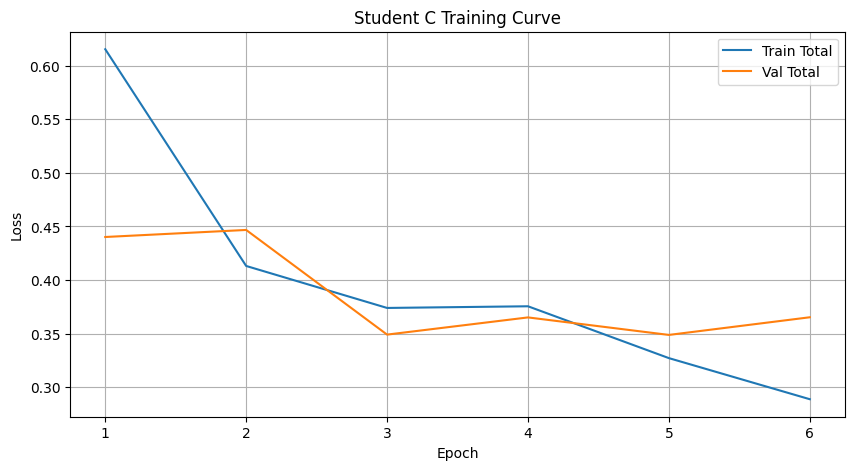

In [42]:
df = pd.read_csv(history_path)

plt.figure(figsize=(10,5))

plt.plot(df["epoch"], df["train_total"], label="Train Total")
plt.plot(df["epoch"], df["val_total"], label="Val Total")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Student C Training Curve")
plt.legend()
plt.grid()

plt.show()

In [44]:
@torch.no_grad()
def run_student_inpaint(model, image_pil, mask_pil, num_sample_steps):
    model.eval()

    image_t = pil_to_tensor_neg1_1(image_pil).unsqueeze(0).to(device).float()
    mask_t = pil_mask_to_tensor(mask_pil).unsqueeze(0).to(device).float()

    masked_pil = apply_mask_to_image(image_pil, mask_pil)
    masked_t = pil_to_tensor_neg1_1(masked_pil).unsqueeze(0).to(device).float()

    latents = encode_image_to_latent(vae, image_t).float()
    masked_latent = encode_image_to_latent(vae, masked_t).float()

    scheduler.set_timesteps(num_sample_steps, device=device)
    latents = torch.randn_like(latents).float()

    for t in scheduler.timesteps:
        t_batch = torch.full((latents.size(0),), int(t), device=device, dtype=torch.long)
        model_input = prepare_input(latents, mask_t, masked_latent).float()
        noise_pred = model(model_input, t_batch).float()
        latents = scheduler.step(noise_pred, t, latents).prev_sample.float()

    vae_dtype = next(vae.parameters()).dtype
    decoded = vae.decode((latents / 0.18215).to(dtype=vae_dtype)).sample
    decoded = decoded.float()

    pred_01 = tensor_neg1_1_to_01(decoded[0])
    pred_pil = tensor_01_to_pil(pred_01)
    return pred_pil

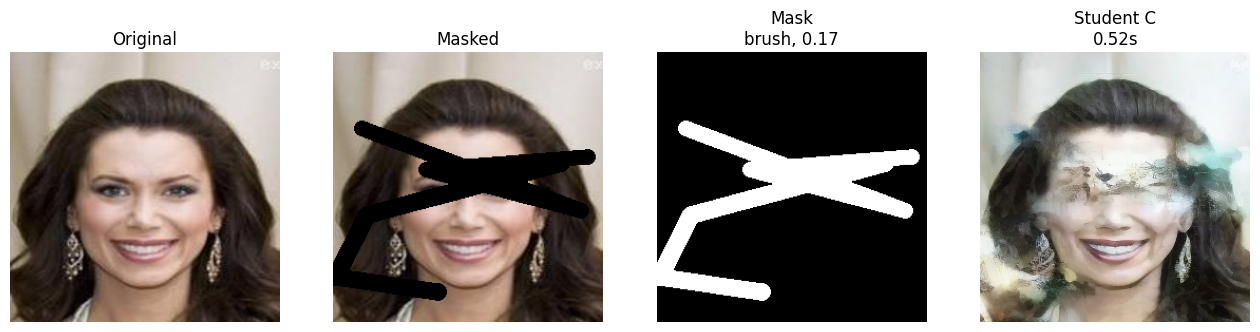

In [45]:
sample = test_ds[0]

orig = sample["image_pil"]
mask, mask_type, area = sample_hybrid_mask_pil(orig.size, CFG["masking"])
masked = apply_mask_to_image(orig, mask)

start = time.time()
pred = run_student_inpaint(model, orig, mask, CFG["num_sample_steps"])
elapsed = time.time() - start

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(masked)
plt.title("Masked")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(mask, cmap="gray")
plt.title(f"Mask\n{mask_type}, {area:.2f}")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(pred)
plt.title(f"Student C\n{elapsed:.2f}s")
plt.axis("off")

plt.show()

In [46]:
GEN_DIR = RESULT_DIR / "gen_images"
REAL_DIR = RESULT_DIR / "real_images"

GEN_DIR.mkdir(parents=True, exist_ok=True)
REAL_DIR.mkdir(parents=True, exist_ok=True)

print("Saving evaluation images...")

for i in tqdm(range(len(test_ds))):
    sample = test_ds[i]

    orig = sample["image_pil"]
    mask, _, _ = sample_hybrid_mask_pil(orig.size, CFG["masking"])

    pred = run_student_inpaint(model, orig, mask, CFG["num_sample_steps"])

    orig.save(REAL_DIR / f"{i}.png")
    pred.save(GEN_DIR / f"{i}.png")

print("Saved images:", len(list(GEN_DIR.glob("*"))))

Saving evaluation images...


  0%|          | 0/100 [00:00<?, ?it/s]

Saved images: 100


In [47]:
lpips_model = lpips.LPIPS(net='alex').to(device)

psnr_list = []
ssim_list = []
lpips_list = []

for i in tqdm(range(len(test_ds))):
    real = Image.open(REAL_DIR / f"{i}.png").convert("RGB")
    fake = Image.open(GEN_DIR / f"{i}.png").convert("RGB")

    real_np = np.array(real)
    fake_np = np.array(fake)

    psnr_list.append(psnr_metric(real_np, fake_np, data_range=255))
    ssim_list.append(ssim_metric(real_np, fake_np, channel_axis=2, data_range=255))

    real_t = torch.tensor(real_np).permute(2,0,1).unsqueeze(0).float().to(device)/127.5 - 1
    fake_t = torch.tensor(fake_np).permute(2,0,1).unsqueeze(0).float().to(device)/127.5 - 1

    lp = lpips_model(real_t, fake_t).item()
    lpips_list.append(lp)

print("PSNR:", np.mean(psnr_list))
print("SSIM:", np.mean(ssim_list))
print("LPIPS:", np.mean(lpips_list))

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


  0%|          | 0/100 [00:00<?, ?it/s]

PSNR: 15.297504592706854
SSIM: 0.5642166544176194
LPIPS: 0.37264348804950714


# As Result performance decreased Than our Student B also.we need better version pf student C v-2